<a href="https://colab.research.google.com/github/LouisJudia/244107020071-Pembelajaran-Mesin/blob/main/JS04_Studi_Kasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Mental Health and Burnout Dataset

Notebook ini membangun dua model clustering pada dataset **Mental Health and Burnout Prediction**:

- **K-Means**
- **DBSCAN**

Tujuan utama:
1. melakukan preprocessing data,
2. mencari parameter terbaik untuk K-Means,
3. menguji DBSCAN,
4. menjelaskan hasil cluster yang terbentuk.

> Catatan: kolom label akhir seperti `Burnout_Risk`, `Mental_Health_Status`, dan `AI_Wellness_Recommendation` **tidak dipakai saat training** karena clustering adalah metode unsupervised. Kolom tersebut hanya digunakan untuk interpretasi hasil cluster.

## 1. Import Library dan Konfigurasi

Library yang dipakai:
- `pandas`, `numpy` untuk pengolahan data,
- `matplotlib`, `seaborn` untuk visualisasi,
- `scikit-learn` untuk preprocessing dan clustering.

Selain itu, beberapa opsi tampilan Pandas dan tema Seaborn diatur untuk kemudahan analisis.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

## 2. Load Dataset

Memuat dataset dari file CSV. Pastikan file `mental_health_burnout_prediction_dataset.csv` sudah tersedia di lingkungan kerja Anda. Kemudian, menampilkan bentuk (shape) dan beberapa baris pertama data untuk pemeriksaan awal.

In [42]:
DATA_PATH = "mental_health_burnout_prediction_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
display(df.head())

Shape dataset: (50000, 40)


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Sleep_Quality,Stress_Level,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Exercise_Frequency,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,3.0,7.0,4.6,Poor,High,74.0,75.0,26.0,18,8.9,Weekly,5.0,9.1,0.3,0.6,3,Yes,Yes,No,Yes,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,5.0,8.0,4.7,Poor,Moderate,58.0,80.0,29.0,37,0.8,Weekly,18.0,12.0,4.9,5.2,3,Yes,Yes,Yes,No,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,8.0,7.0,6.3,Average,Moderate,54.0,55.0,44.0,48,6.9,Daily,NaN,10.2,6.7,4.7,3,Yes,No,No,No,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,2.0,9.0,7.1,Good,Low,12.0,11.0,88.0,80,7.6,Weekly,55.0,3.3,5.0,4.8,6,Yes,No,No,No,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,1.0,4.0,9.1,Excellent,Low,25.0,48.0,67.0,76,6.1,Never,9.0,6.5,1.3,5.7,8,Yes,No,No,No,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


## 3. Pengecekan Awal Data

Bagian ini melihat:
- daftar kolom,
- tipe data,
- nilai kosong (missing values),
- distribusi ringkas fitur numerik (statistik deskriptif).

In [40]:
print("Kolom dataset:")
print(df.columns.tolist())

print("\nInfo singkat:")
print(df.info())

print("\nMissing values per kolom:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nStatistik deskriptif kolom numerik:")
display(df.describe(include=[np.number]).T)

Kolom dataset:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']

Info singkat:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --

,0
Monthly_Income_USD,1450
Meditation_Minutes,1200
Physical_Activity_Hours,1100
Sleep_Hours,950
Productivity_Score,950
Mood_Score,900
Depression_Score,850
Screen_Time_Hours,850
Anxiety_Score,800
Gaming_Hours,750



Statistik deskriptif kolom numerik:


,count,mean,std,min,25%,50%,75%,max
Person_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49750.0,41.448181,13.871634,18.0,29.00,41.0,53.00,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.00,6231.0,9134.00,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.00,45.0,58.00,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.00,6.0,8.00,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.50,7.0,8.50,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.00,39.0,59.00,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.00,39.0,60.00,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.00,61.0,80.00,100.0


## 4. Menentukan Fitur untuk Clustering

Untuk clustering, kita gunakan fitur numerik agar jarak antar data lebih stabil. Kolom yang tidak relevan atau merupakan label target akhir seperti `Person_ID`, `Burnout_Risk`, `Mental_Health_Status`, dan `AI_Wellness_Recommendation` akan dibuang dari kumpulan fitur untuk clustering.

In [43]:
drop_cols = ["Person_ID", "Burnout_Risk", "Mental_Health_Status", "AI_Wellness_Recommendation"]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in drop_cols]

X = df[feature_cols].copy()

print("Jumlah fitur numerik yang dipakai:", len(feature_cols))
print("Fitur:", feature_cols)
print("\nShape X:", X.shape)

Jumlah fitur numerik yang dipakai: 20
Fitur: ['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Shape X: (50000, 20)


## 5. Preprocessing Data

Langkah preprocessing meliputi:
1.  **Imputasi median** untuk nilai hilang (missing values).
2.  **Standardisasi** agar skala tiap fitur sebanding, karena algoritma clustering berbasis jarak sensitif terhadap skala fitur.
3.  **PCA (Principal Component Analysis)** untuk mereduksi dimensi. PCA dipilih dengan target mempertahankan sekitar 95% variasi data, yang dapat membantu visualisasi serta stabilitas clustering.

In [44]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocess.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape setelah scaling:", X_scaled.shape)
print("Shape setelah PCA:", X_pca.shape)
print("Total explained variance PCA:", pca.explained_variance_ratio_.sum())

Shape setelah scaling: (50000, 20)
Shape setelah PCA: (50000, 14)
Total explained variance PCA: 0.9676809914784823


## 6. Evaluasi K-Means untuk Menentukan `k` Terbaik

Kita uji beberapa nilai `k` (jumlah cluster) dan membandingkan metrik evaluasi clustering. Untuk efisiensi, evaluasi dilakukan pada sampel data.

Metrik yang digunakan:
-   **Silhouette Score**: Semakin besar semakin baik (mendekati 1).
-   **Calinski-Harabasz Index**: Semakin besar semakin baik.
-   **Davies-Bouldin Index**: Semakin kecil semakin baik (mendekati 0).

Setelah evaluasi, nilai `k` terbaik akan dipilih berdasarkan metrik ini.

In [45]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_pca.shape[0], size=min(10000, X_pca.shape[0]), replace=False)
X_sample = X_pca[sample_idx]

k_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    k_results.append({
        "k": k,
        "silhouette": silhouette_score(X_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_sample, labels),
        "inertia": km.inertia_
    })

k_df = pd.DataFrame(k_results)
display(k_df)

best_k = int(k_df.sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False]).iloc[0]["k"])
print("k terbaik berdasarkan evaluasi:", best_k)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia
0,2,0.195356,3030.216582,1.798312,147769.106848
1,3,0.109453,2004.593573,2.432051,137437.396511
2,4,0.069603,1471.435836,3.120155,133570.005081
3,5,0.070164,1191.257838,3.109058,130392.155155
4,6,0.066788,1009.003432,3.206672,127960.575583
5,7,0.056213,883.873643,3.401162,125795.827361
6,8,0.055425,788.885677,3.262092,124016.238606
7,9,0.054839,715.761571,3.244742,122403.078737
8,10,0.052595,654.333819,3.178918,121142.743738


k terbaik berdasarkan evaluasi: 2


### Visualisasi Metrik Evaluasi K-Means

Grafik di bawah menunjukkan bagaimana nilai metrik Silhouette, Calinski-Harabasz, dan Davies-Bouldin berubah seiring dengan peningkatan jumlah cluster (k). Ini membantu dalam menentukan `k` yang optimal secara visual.

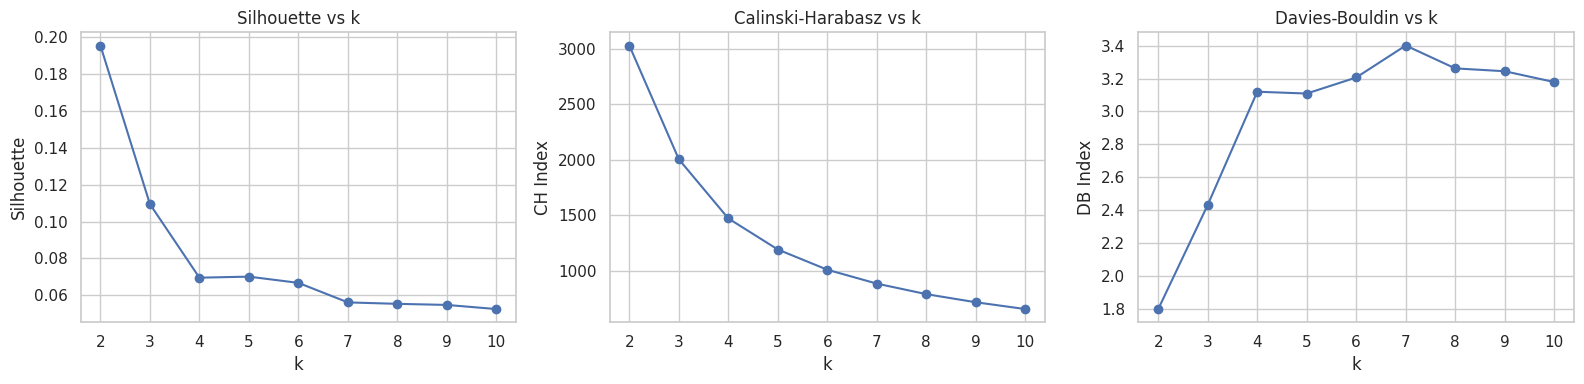

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(k_df["k"], k_df["silhouette"], marker="o")
ax[0].set_title("Silhouette vs k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Silhouette")

ax[1].plot(k_df["k"], k_df["calinski_harabasz"], marker="o")
ax[1].set_title("Calinski-Harabasz vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("CH Index")

ax[2].plot(k_df["k"], k_df["davies_bouldin"], marker="o")
ax[2].set_title("Davies-Bouldin vs k")
ax[2].set_xlabel("k")
ax[2].set_ylabel("DB Index")

plt.tight_layout()
plt.show()

## 7. Model K-Means Final dan Interpretasi

Setelah evaluasi, kita fit model K-Means final menggunakan `k` terbaik yang telah ditemukan. Kemudian, kita akan melihat distribusi cluster yang terbentuk, profil rata-rata dan median fitur numerik di setiap cluster, serta komposisi label asli (Burnout_Risk dan Mental_Health_Status) di setiap cluster untuk interpretasi.

In [47]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans_final.fit_predict(X_pca)

print("Distribusi cluster K-Means:")
display(df["KMeans_Cluster"].value_counts().sort_index())

print("\nProfil mean fitur numerik per cluster:")
display(df.groupby("KMeans_Cluster")[feature_cols].mean())

print("\nProfil median fitur numerik per cluster:")
display(df.groupby("KMeans_Cluster")[feature_cols].median())

print("\nKomposisi Burnout_Risk per cluster (%)")
burnout_comp = pd.crosstab(df["KMeans_Cluster"], df["Burnout_Risk"], normalize="index") * 100
display(burnout_comp.round(2))

print("\nKomposisi Mental_Health_Status per cluster (%)")
mental_comp = pd.crosstab(df["KMeans_Cluster"], df["Mental_Health_Status"], normalize="index") * 100
display(mental_comp.round(2))

Distribusi cluster K-Means:


,count
KMeans_Cluster,
0,26664
1,23336



Profil mean fitur numerik per cluster:


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,41.461730,6279.805416,37.156878,5.511605,5.503839,7.301461,20.596043,20.956077,79.285174,79.137301,5.420025,33.264077,7.030681,3.969679,2.995791,3.456646,5.520301,79.022815,14.978360,20.590647
1,41.432727,6218.605356,53.846289,5.484690,5.505035,6.650227,63.125223,63.037394,37.131080,36.809565,4.494250,26.323647,9.088615,4.016834,2.979593,4.602503,5.522439,37.055762,14.960919,62.609916



Profil median fitur numerik per cluster:


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,41.0,6288.0,35.0,6.0,6.0,7.5,21.0,21.0,79.0,79.0,5.6,35.0,6.6,4.0,3.0,3.0,6.0,79.0,15.0,20.0
1,41.0,6174.5,56.0,5.0,6.0,6.5,61.0,61.0,40.0,39.0,4.3,24.0,9.5,4.0,3.0,5.0,6.0,39.0,15.0,61.0



Komposisi Burnout_Risk per cluster (%)


Burnout_Risk,High,Low,Moderate
KMeans_Cluster,,,
0,0.00,88.56,11.44
1,42.21,7.52,50.26



Komposisi Mental_Health_Status per cluster (%)


Mental_Health_Status,Critical,Healthy,Needs Attention
KMeans_Cluster,,,
0,0.00,88.56,11.44
1,45.14,7.52,47.33


### Visualisasi K-Means pada PCA 2D

Visualisasi data setelah direduksi dimensinya menjadi 2 komponen utama (PCA 2D) dengan warna yang menunjukkan cluster K-Means yang terbentuk. Ini membantu dalam memahami pemisahan cluster secara visual.

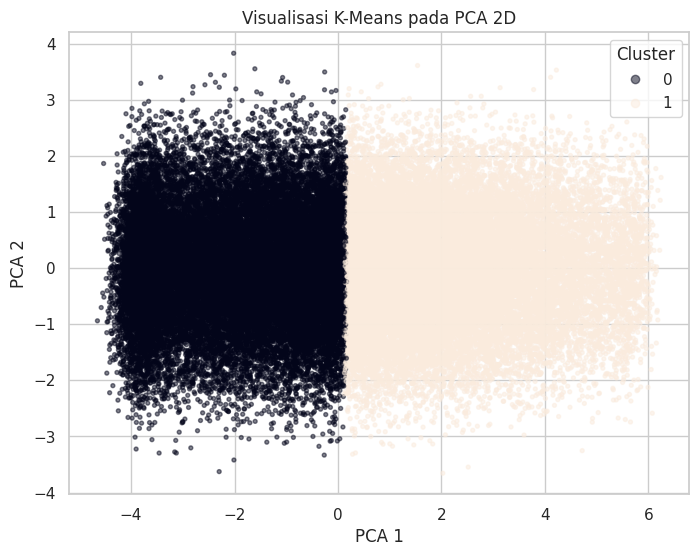

In [48]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["KMeans_Cluster"], s=8, alpha=0.5)
plt.title("Visualisasi K-Means pada PCA 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

## 8. DBSCAN

DBSCAN adalah algoritma clustering berbasis densitas yang sangat sensitif terhadap parameter `eps` (radius) dan `min_samples` (jumlah sampel minimum). Kita akan melakukan langkah-langkah berikut:

1.  **Sampling Data**: Mengambil sampel data untuk mempercepat proses tuning DBSCAN.
2.  **K-Distance Graph**: Menggunakan plot k-distance untuk membantu menentukan kandidat nilai `eps` yang optimal.
3.  **Evaluasi DBSCAN**: Menguji beberapa kandidat `eps` dan mengevaluasi hasilnya berdasarkan jumlah cluster, tingkat noise, dan Silhouette Score.
4.  **Model DBSCAN Final**: Menerapkan model DBSCAN dengan `eps` terbaik pada seluruh data.

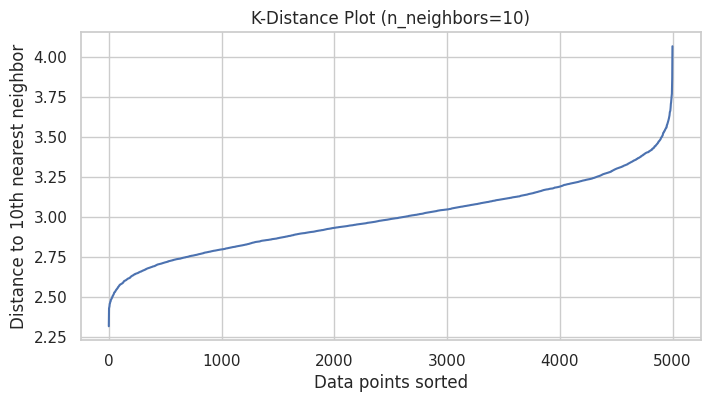

Kandidat eps: [2.718 2.762 2.801 2.841 2.873 2.908 2.939 2.966 2.996 3.029 3.061 3.094
 3.127 3.171 3.214 3.267 3.347 3.498]


,eps,clusters,noise_rate,silhouette
0,2.718,11,0.5134,-0.229063
1,2.762,6,0.3922,-0.156163
2,2.801,2,0.2992,-0.011381
3,2.841,2,0.2292,0.012591
4,2.873,1,0.1760,NaN
5,2.908,1,0.1354,NaN
6,2.939,1,0.1002,NaN
7,2.966,2,0.0724,0.043169
8,2.996,1,0.0510,NaN
9,3.029,1,0.0356,NaN


eps terpilih: 2.966
Distribusi cluster DBSCAN:
{np.int64(-1): np.int64(2), np.int64(0): np.int64(49998)}

Jumlah cluster (tanpa noise): 1
Noise rate: 0.0


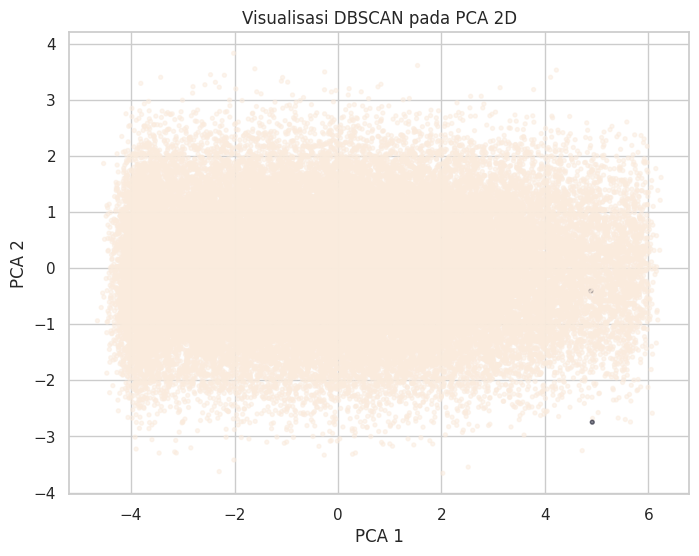

In [49]:
db_sample_idx = rng.choice(X_pca.shape[0], size=min(5000, X_pca.shape[0]), replace=False)
X_db = X_pca[db_sample_idx]

nbrs = NearestNeighbors(n_neighbors=10)
nbrs.fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kdist)
plt.title("K-Distance Plot (n_neighbors=10)")
plt.xlabel("Data points sorted")
plt.ylabel("Distance to 10th nearest neighbor")
plt.show()

eps_candidates = np.unique(np.round(np.quantile(kdist, np.linspace(0.10, 0.98, 18)), 3))
print("Kandidat eps:", eps_candidates)

db_results = []
for eps in eps_candidates:
    labels = DBSCAN(eps=float(eps), min_samples=10).fit_predict(X_db)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float((labels == -1).mean())

    sil = None
    if n_clusters >= 2:
        try:
            sil = silhouette_score(X_db, labels)
        except Exception:
            sil = None

    db_results.append({
        "eps": float(eps),
        "clusters": int(n_clusters),
        "noise_rate": noise_rate,
        "silhouette": sil
    })

db_df = pd.DataFrame(db_results)
display(db_df)

db_valid = db_df[db_df["clusters"] >= 2].copy()
if len(db_valid) > 0:
    db_valid["score"] = db_valid["silhouette"].fillna(-999)
    best_db_row = db_valid.sort_values(["score", "noise_rate"], ascending=[False, True]).iloc[0]
    best_eps = float(best_db_row["eps"])
else:
    best_eps = float(db_df.iloc[0]["eps"])

print("eps terpilih:", best_eps)

dbscan_final = DBSCAN(eps=best_eps, min_samples=10)
db_labels = dbscan_final.fit_predict(X_pca)
df["DBSCAN_Cluster"] = db_labels

unique, counts = np.unique(db_labels, return_counts=True)
print("Distribusi cluster DBSCAN:")
print(dict(zip(unique, counts)))

n_clusters_final = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_rate_final = (db_labels == -1).mean()

print("\nJumlah cluster (tanpa noise):", n_clusters_final)
print("Noise rate:", round(noise_rate_final, 4))

if n_clusters_final >= 2:
    print("Silhouette DBSCAN:", silhouette_score(X_pca, db_labels))

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=db_labels, s=8, alpha=0.5)
plt.title("Visualisasi DBSCAN pada PCA 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## 9. Simpan Hasil Cluster

Cell ini menyimpan dataframe yang sudah ditambahkan kolom cluster hasil K-Means dan DBSCAN ke dalam file CSV baru. Ini berguna jika Anda ingin menggunakan hasil clustering ini untuk analisis lebih lanjut di luar notebook ini.

In [50]:
output_path = "mental_health_burnout_clustered.csv"
df.to_csv(output_path, index=False)
print("File tersimpan:", output_path)

File tersimpan: mental_health_burnout_clustered.csv
